In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Configure visual style for charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# ==============================================================================
# 1. DATA LOADING AND STRICT FILTERING
# ==============================================================================
df = pd.read_csv("organometallic_ml_ready_matrix.csv")

# Strict outlier filtration to preserve scientific integrity
df = df[(df['pIC50'] > 2) & (df['pIC50'] < 12)].dropna(subset=['chemical_formula'])
df = df[(df['computed_molecular_weight'] <= 1016.1) & (df['computed_molecular_weight'] >= 11.4)]
print(f"Filtered dataset shape for Phase 4: Rows = {df.shape[0]}, Columns = {df.shape[1]}")


# ==============================================================================
# 2. ADVANCED METAL-AWARE FEATURE ENGINEERING
# ==============================================================================
print("\nExecuting advanced metal-aware feature engineering pipeline...")

# Robust elemental parser from Phase 3, updated with halogen counting
def parse_formula_robust(formula):
    if not isinstance(formula, str):
        return [0, 0, 0, 0, 0] # C, N, O, H, Cl/Halogens

    def count_element(element, text):
        matches = re.findall(rf'{element}(\d*)', text)
        total = 0
        for m in matches:
            if m == '':
                total += 1
            else:
                total += int(m)
        return total

    # Extract halogen count (specifically Chlorine/Bromine/Iodine acting as leaving groups)
    cl_count = count_element('Cl', formula)
    br_count = count_element('Br', formula)
    i_count = count_element('I', formula)
    total_halogens = cl_count + br_count + i_count

    return [
        count_element('C', formula),
        count_element('N', formula),
        count_element('O', formula),
        count_element('H', formula),
        total_halogens
    ]

element_data = df['chemical_formula'].apply(parse_formula_robust).tolist()
df_elements = pd.DataFrame(element_data, columns=['atom_C', 'atom_N', 'atom_O', 'atom_H', 'leaving_groups'], index=df.index)

# Isolate base physical parameters
df_features = df[['computed_molecular_weight', 'total_atom_count', 'net_charge']].copy()
df_features = pd.concat([df_features, df_elements], axis=1)

# Recompute correct approximations for polar surface area and hydrogen bond counts
df_features['HBA_approx'] = df_features['atom_N'] + df_features['atom_O']
df_features['TPSA_approx'] = (df_features['atom_N'] * 15.8) + (df_features['atom_O'] * 9.2)

# Define expert mappings for transition metal properties (Atomic Number & Electronegativity)
metal_properties = {
    'metal_Pt': {'atomic_number': 78, 'electronegativity': 2.28},
    'metal_Ru': {'atomic_number': 44, 'electronegativity': 2.20},
    'metal_Au': {'atomic_number': 79, 'electronegativity': 2.54},
    'metal_Fe': {'atomic_number': 26, 'electronegativity': 1.83},
    'metal_Os': {'atomic_number': 76, 'electronegativity': 2.20},
    'metal_Pd': {'atomic_number': 46, 'electronegativity': 2.20}
}

# Initialize advanced metal-aware coordinate columns
df_features['metal_atomic_number'] = 0
df_features['metal_electronegativity'] = 0.0
df_features['coordination_number_approx'] = 0
df_features['oxidation_state'] = 0
df_features['aromatic_ligand_presence'] = 0

# Vectorized rule-based extraction of metal centers and coordination metrics
for metal_col, props in metal_properties.items():
    mask = df[metal_col] == 1
    df_features.loc[mask, 'metal_atomic_number'] = props['atomic_number']
    df_features.loc[mask, 'metal_electronegativity'] = props['electronegativity']

# Rule 1: Approximating coordination number based on heteroatom donors and leaving groups
df_features['coordination_number_approx'] = (df_features['atom_N'] + df_features['leaving_groups']).clip(2, 6)

# Rule 2: Curated mapping for oxidation states based on metal identity and net charge trends
df_features.loc[(df['metal_Pt'] == 1) & (df_features['net_charge'] <= 0), 'oxidation_state'] = 2
df_features.loc[(df['metal_Pt'] == 1) & (df_features['net_charge'] > 0), 'oxidation_state'] = 2
df_features.loc[(df['metal_Pt'] == 1) & (df_features['leaving_groups'] >= 4), 'oxidation_state'] = 4

# For Ru/Fe/Os: typically present as Ru(II) arene complexes or Fe(II) ferrocenes in anticancer screens
df_features.loc[(df['metal_Ru'] == 1) | (df['metal_Fe'] == 1) | (df['metal_Os'] == 1), 'oxidation_state'] = 2

# For Au: primarily Au(I) linear or Au(III) square-planar configurations
df_features.loc[(df['metal_Au'] == 1) & (df_features['net_charge'] <= 0), 'oxidation_state'] = 1
df_features.loc[(df['metal_Au'] == 1) & (df_features['net_charge'] > 0), 'oxidation_state'] = 3

# Rule 3: Identifying potential flat aromatic DNA-intercalating environments
df_features.loc[(df_features['atom_C'] >= 10) & (df_features['atom_N'] >= 2), 'aromatic_ligand_presence'] = 1

# Extract target array
y = df['pIC50']

print(f"Advanced Metal-Aware Matrix constructed: Total features = {df_features.shape[1]}")
print("\nGenerated Metal-Aware Feature Samples (Head view):")
print(df_features[['metal_atomic_number', 'metal_electronegativity', 'coordination_number_approx', 'oxidation_state', 'leaving_groups']].head())

Filtered dataset shape for Phase 4: Rows = 1672, Columns = 17

Executing advanced metal-aware feature engineering pipeline...
Advanced Metal-Aware Matrix constructed: Total features = 15

Generated Metal-Aware Feature Samples (Head view):
   metal_atomic_number  metal_electronegativity  coordination_number_approx  \
0                   78                     2.28                           4   
1                   78                     2.28                           4   
2                   78                     2.28                           4   
3                   78                     2.28                           4   
4                   78                     2.28                           4   

   oxidation_state  leaving_groups  
0                2               2  
1                2               2  
2                2               2  
3                2               2  
4                2               2  


In [6]:
# ==============================================================================
# 3. MODEL TRAINING & EVALUATION
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(df_features, y, test_size=0.2, random_state=42)

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostRegressor(n_estimators=150, learning_rate=0.1, random_state=42, verbose=0)
}

results_phase4 = []

print("\n=======================================================")
print("  MODEL REGRESSION RESULTS: METAL-AWARE ENG. (PHASE 4) ")
print("=======================================================")

for name, model in models.items():
    model.fit(X_train, y_train)
    p_train = model.predict(X_train)
    p_test = model.predict(X_test)
    
    r2_train = r2_score(y_train, p_train)
    r2_test = r2_score(y_test, p_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, p_test))
    gap = r2_train - r2_test
    
    results_phase4.append({
        "Model": name,
        "Train R²": r2_train,
        "Test R²": r2_test,
        "Test RMSE": rmse_test,
        "Overfitting Gap": gap
    })
    
    print(f"{name}:")
    print(f"  Train R²: {r2_train:.3f} | Test R²: {r2_test:.3f}")
    print(f"  Test RMSE: {rmse_test:.3f} | Overfitting Gap: {gap:.3f}\n")

# Process results array into a clean standalone dataframe for terminal reporting
df_res_p4 = pd.DataFrame(results_phase4)

print("=======================================================")
print("SUMMARY METAL-AWARE DESIGN EVALUATION MATRIX")
print("=======================================================")
print(df_res_p4.to_string(index=False, columns=["Model", "Train R²", "Test R²", "Test RMSE", "Overfitting Gap"]))
print("=======================================================\n")


  MODEL REGRESSION RESULTS: METAL-AWARE ENG. (PHASE 4) 
Random Forest:
  Train R²: 0.512 | Test R²: 0.484
  Test RMSE: 0.572 | Overfitting Gap: 0.028

XGBoost:
  Train R²: 0.511 | Test R²: 0.470
  Test RMSE: 0.579 | Overfitting Gap: 0.041

LightGBM:
  Train R²: 0.501 | Test R²: 0.470
  Test RMSE: 0.579 | Overfitting Gap: 0.031

CatBoost:
  Train R²: 0.461 | Test R²: 0.452
  Test RMSE: 0.589 | Overfitting Gap: 0.010

SUMMARY METAL-AWARE DESIGN EVALUATION MATRIX
        Model  Train R²  Test R²  Test RMSE  Overfitting Gap
Random Forest  0.512228 0.483782   0.571660         0.028446
      XGBoost  0.510943 0.470168   0.579149         0.040775
     LightGBM  0.500905 0.469573   0.579474         0.031332
     CatBoost  0.461427 0.451771   0.589118         0.009656




Running dimensionality reduction on advanced metal-aware features...


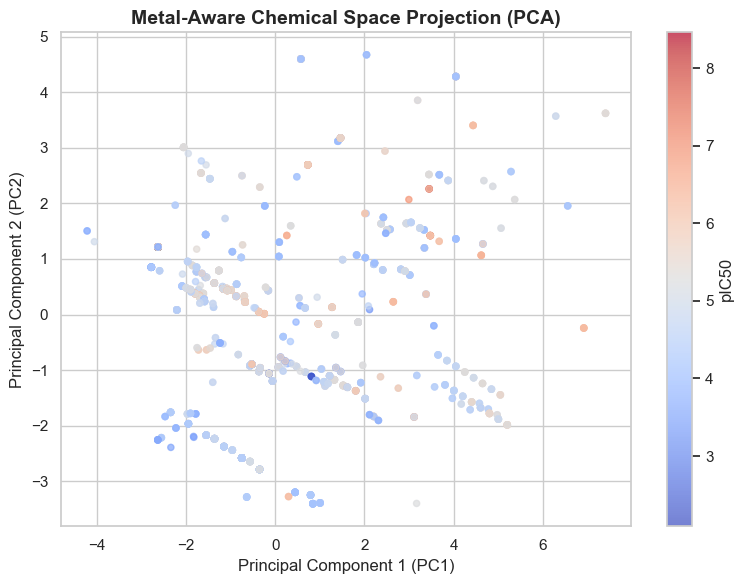

  Computing advanced t-SNE manifold...


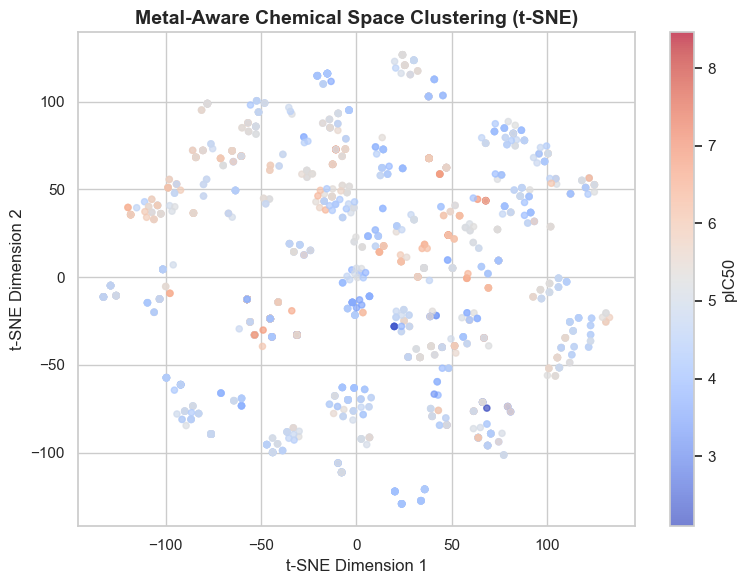


  NEW ADVANCED PCA FEATURE LOADINGS (PHASE 4)          
                            PC1_Weight  PC2_Weight
total_atom_count              0.389470   -0.195078
computed_molecular_weight     0.387410   -0.030418
atom_C                        0.381588   -0.173287
aromatic_ligand_presence      0.350034    0.022975
atom_H                        0.323244   -0.265924
HBA_approx                    0.318245    0.145451
TPSA_approx                   0.316850    0.276570
atom_N                        0.231228    0.470686
atom_O                        0.204254   -0.227171
net_charge                    0.098453    0.239913
coordination_number_approx    0.096879    0.515156
metal_electronegativity      -0.014085    0.019545
oxidation_state              -0.016881    0.167229
metal_atomic_number          -0.019910    0.010905
leaving_groups               -0.093745    0.370861



In [10]:
# Import missing dimensionality reduction tools for Phase 4
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ==============================================================================
# 4. DIMENSIONALITY REDUCTION ON EXPANDED SPACE (PCA & T-SNE) - SEPARATE PLOTS
# ==============================================================================
print("\nRunning dimensionality reduction on advanced metal-aware features...")

# Scale the expanded 15-feature matrix
X_scaled_p4 = StandardScaler().fit_transform(df_features)

# ------------------------------------------------------------------------------
# Plot 1: Principal Component Analysis (PCA)
# ------------------------------------------------------------------------------
pca_p4 = PCA(n_components=2, random_state=42)
X_pca_p4 = pca_p4.fit_transform(X_scaled_p4)

plt.figure(figsize=(8, 6))
scatter_pca = plt.scatter(X_pca_p4[:, 0], X_pca_p4[:, 1], c=y, cmap='coolwarm', alpha=0.7, s=20)
plt.colorbar(scatter_pca, label='pIC50')
plt.title('Metal-Aware Chemical Space Projection (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Plot 2: t-Distributed Stochastic Neighbor Embedding (t-SNE)
# ------------------------------------------------------------------------------
print("  Computing advanced t-SNE manifold...")
tsne_p4 = TSNE(n_components=2, perplexity=35, random_state=42)
X_tsne_p4 = tsne_p4.fit_transform(X_scaled_p4)

plt.figure(figsize=(8, 6))
scatter_tsne = plt.scatter(X_tsne_p4[:, 0], X_tsne_p4[:, 1], c=y, cmap='coolwarm', alpha=0.7, s=20)
plt.colorbar(scatter_tsne, label='pIC50')
plt.title('Metal-Aware Chemical Space Clustering (t-SNE)', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Output PCA Loadings for Text Analysis
# ------------------------------------------------------------------------------
loadings_p4 = pd.DataFrame(pca_p4.components_.T, columns=['PC1_Weight', 'PC2_Weight'], index=df_features.columns)
print("\n=======================================================")
print("  NEW ADVANCED PCA FEATURE LOADINGS (PHASE 4)          ")
print("=======================================================")
print(loadings_p4.sort_values(by='PC1_Weight', ascending=False))
print("=======================================================\n")

In [11]:
print('--- Top 3 features contributing most to PC1 ---')
print(loadings_p4['PC1_Weight'].sort_values(ascending=False)[:3])
print('--- Top 3 features contributing most to PC2 ---')
print(loadings_p4['PC2_Weight'].sort_values(ascending=False)[:3])
print('--- Top 3 features contributing least to PC2 ---')
print(loadings_p4['PC2_Weight'].sort_values(ascending=True)[:3])

--- Top 3 features contributing most to PC1 ---
total_atom_count             0.389470
computed_molecular_weight    0.387410
atom_C                       0.381588
Name: PC1_Weight, dtype: float64
--- Top 3 features contributing most to PC2 ---
coordination_number_approx    0.515156
atom_N                        0.470686
leaving_groups                0.370861
Name: PC2_Weight, dtype: float64
--- Top 3 features contributing least to PC2 ---
atom_H             -0.265924
atom_O             -0.227171
total_atom_count   -0.195078
Name: PC2_Weight, dtype: float64



Executing K-Means clustering on the new metal-aware t-SNE space...

  METAL-AWARE CHEMICAL PROFILE PER T-SNE ISLAND (P4)  
tsne_cluster_p4                 0      1      2      3      4      5
computed_molecular_weight  604.88 368.87 415.02 510.30 451.35 691.69
total_atom_count            57.82  20.00  25.85  42.17  27.64  53.67
net_charge                   0.33   1.33   0.01   0.02   0.07   3.38
atom_C                      20.10   5.26   6.02  12.33   7.29  20.37
atom_N                       2.45   1.43   1.95   0.62   2.70   4.87
atom_O                       3.97   0.73   2.07   2.79   0.08   0.65
atom_H                      29.56   9.55  13.50  22.59  14.42  19.08
leaving_groups               1.17   1.27   2.04   0.00   2.45   0.52
HBA_approx                   6.41   2.16   4.02   3.41   2.78   5.52
TPSA_approx                 75.14  29.35  49.80  35.48  43.38  82.86
metal_atomic_number         76.12  75.69  77.03  78.00  77.29  72.35
metal_electronegativity      2.27   2.30   2.29 

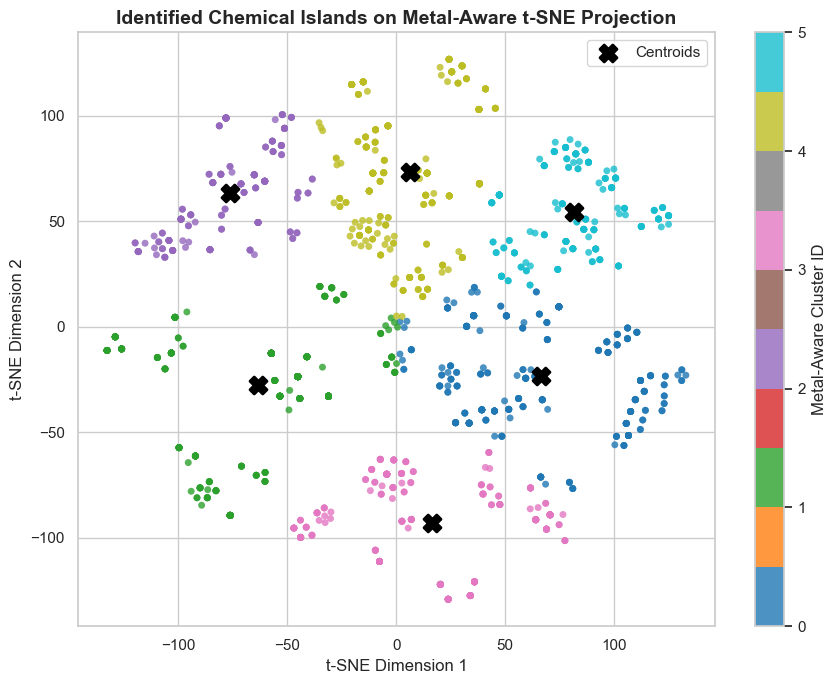

In [14]:
from sklearn.cluster import KMeans

# ==============================================================================
# 5. K-MEANS CLUSTERING & CHEMICAL PROFILING ON NEW T-SNE MANIFOLD
# ==============================================================================
print("\nExecuting K-Means clustering on the new metal-aware t-SNE space...")

# Define the optimal cluster count consistent with Phase 3 baseline
n_clusters_p4 = 6

# Fit KMeans on the 2D t-SNE coordinates for tight, manifold-aligned boundaries
kmeans_p4 = KMeans(n_clusters=n_clusters_p4, init='k-means++', n_init=10, random_state=42)
df_features['tsne_cluster_p4'] = kmeans_p4.fit_predict(X_tsne_p4)

# Append the biological target vector for comprehensive profile mapping
df_features['pIC50_target'] = y

# Calculate the mean chemical and coordination profile for each newly formed island
cluster_profiles_p4 = df_features.groupby('tsne_cluster_p4').mean().T

print("\n=======================================================")
print("  METAL-AWARE CHEMICAL PROFILE PER T-SNE ISLAND (P4)  ")
print("=======================================================")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print(cluster_profiles_p4)
print("=======================================================\n")

# ------------------------------------------------------------------------------
# Visualization: Isolated Cluster Mapping
# ------------------------------------------------------------------------------
plt.figure(figsize=(9, 7))
scatter_clusters = plt.scatter(
    X_tsne_p4[:, 0], 
    X_tsne_p4[:, 1], 
    c=df_features['tsne_cluster_p4'], 
    cmap='tab10', 
    alpha=0.8, 
    s=25, 
    edgecolors='none'
)

# Overlay cluster centroids for geometric reference
centroids_p4 = kmeans_p4.cluster_centers_
plt.scatter(
    centroids_p4[:, 0], 
    centroids_p4[:, 1], 
    marker='X', 
    s=150, 
    linewidths=2, 
    color='black', 
    label='Centroids'
)

plt.colorbar(scatter_clusters, label='Metal-Aware Cluster ID')
plt.title('Identified Chemical Islands on Metal-Aware t-SNE Projection', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# сравнить результаты 2, 3, 4 фаз!!!